In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


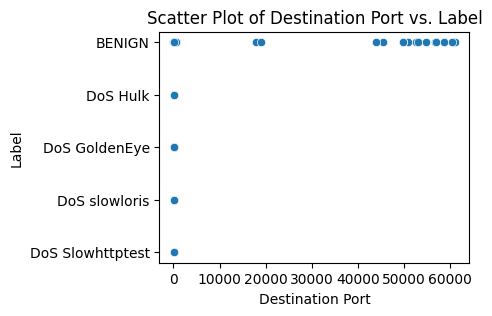

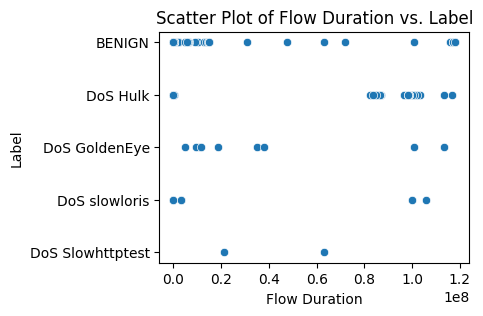

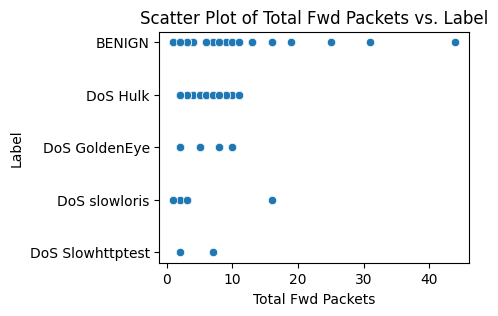

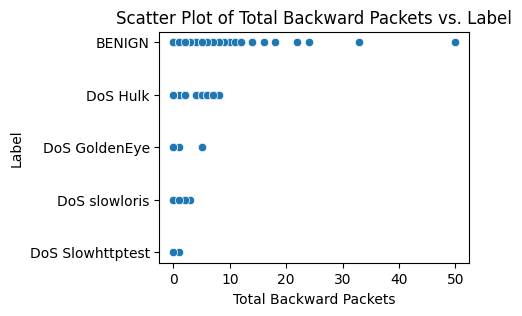

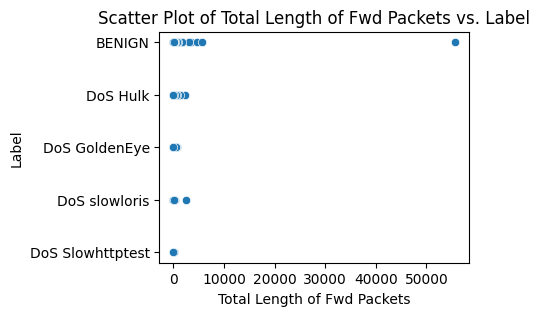

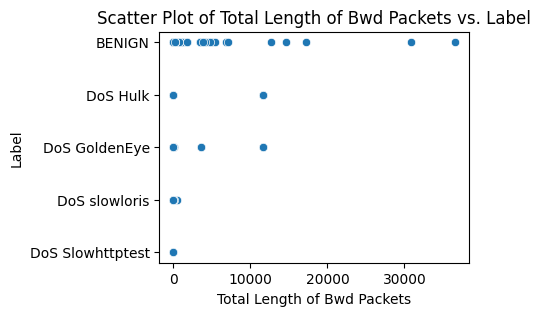

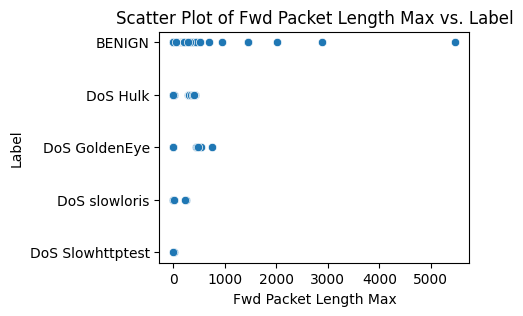

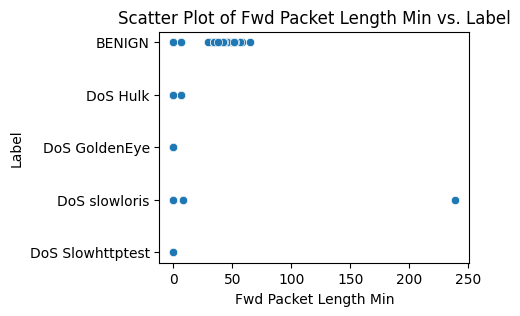

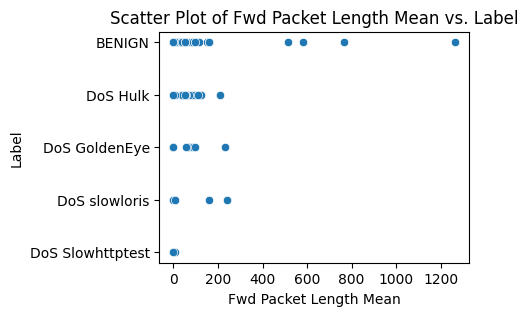

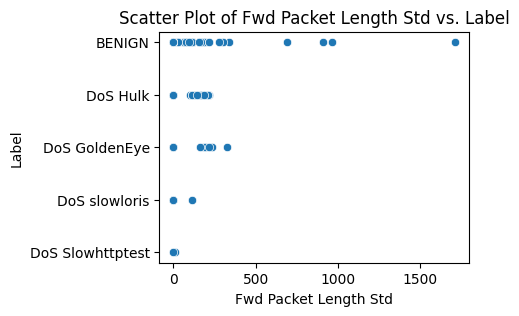

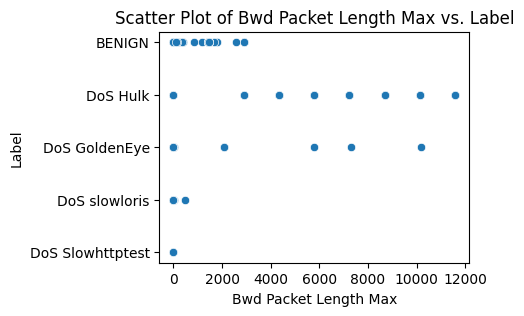

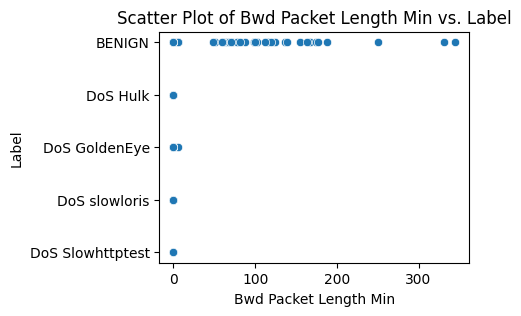

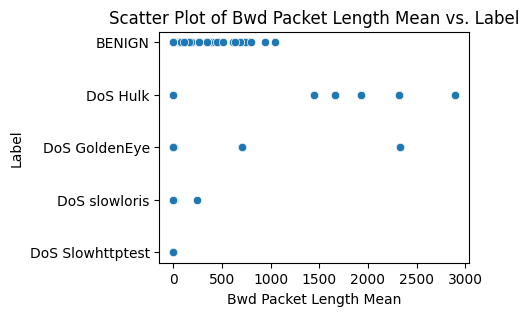

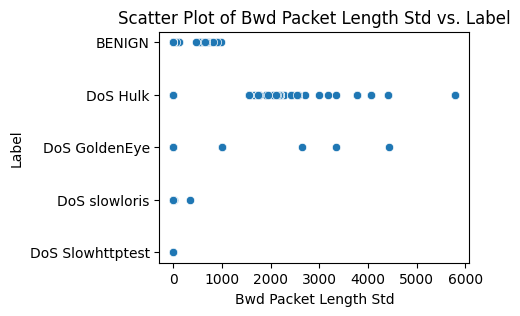

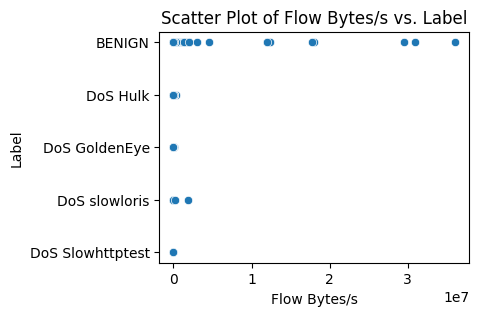

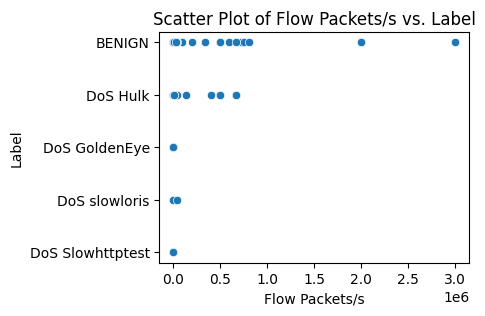

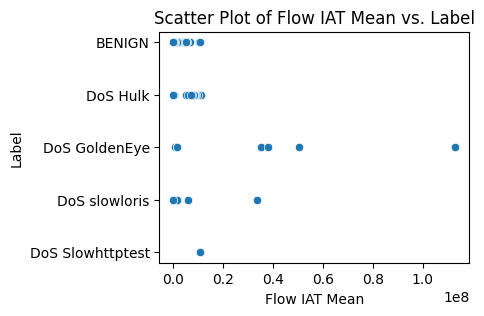

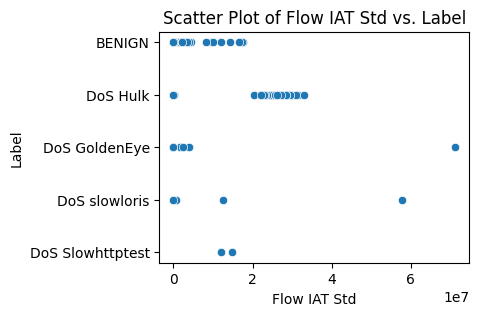

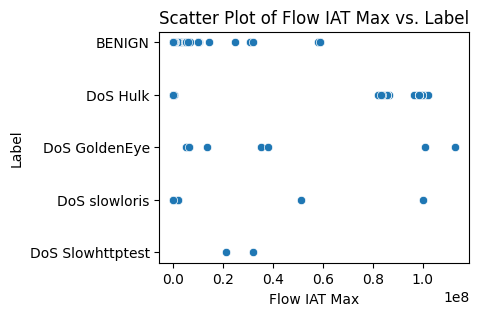

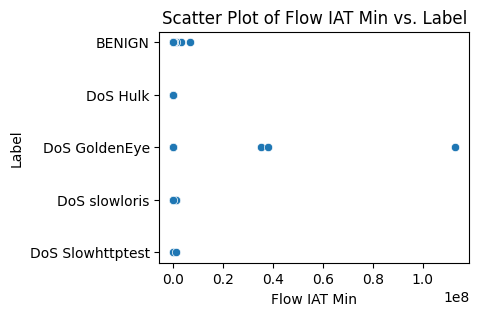

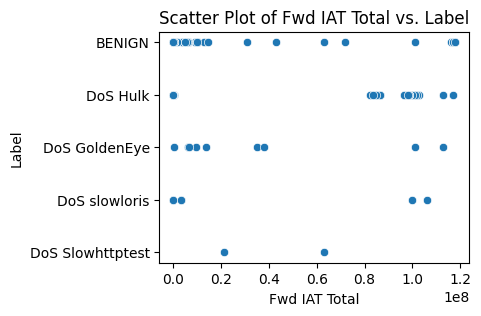

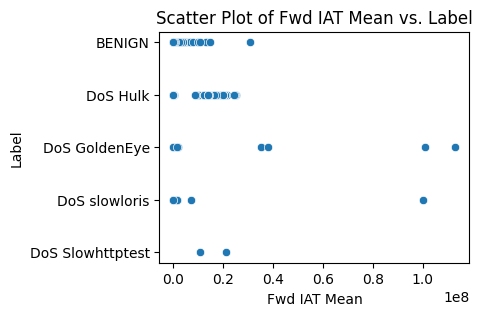

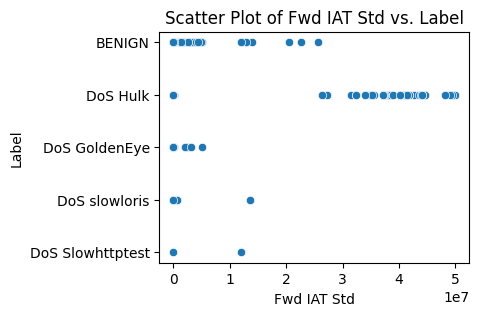

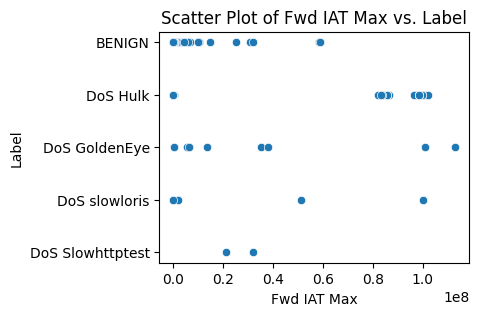

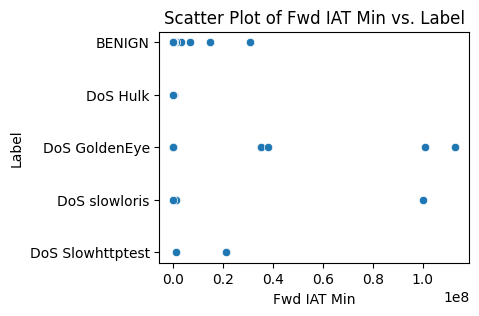

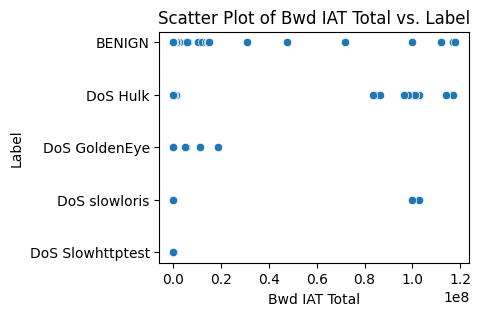

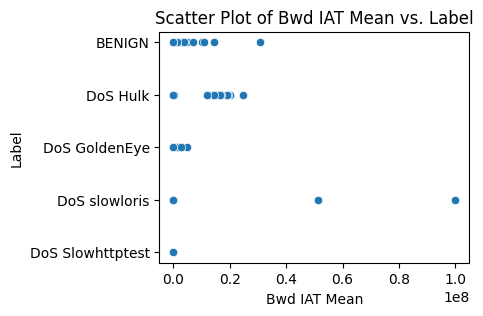

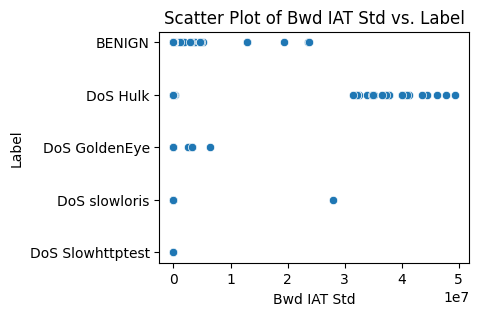

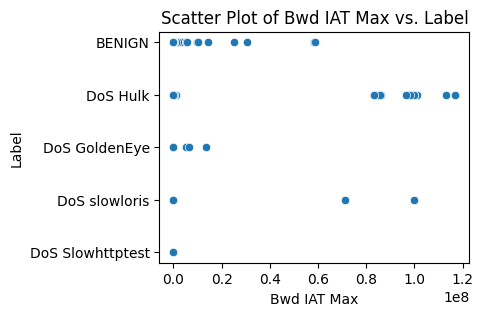

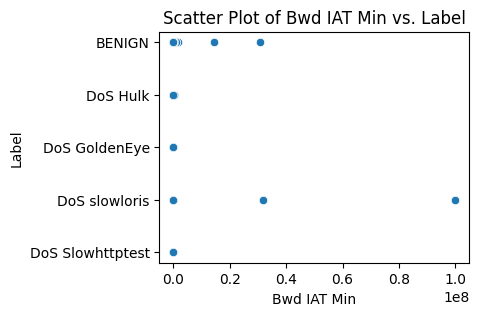

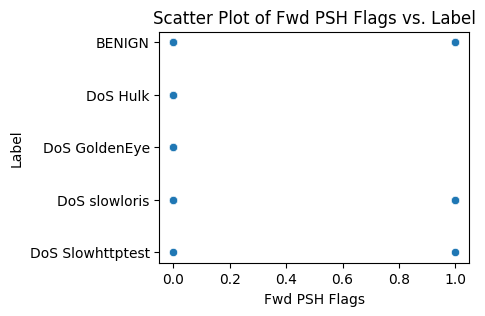

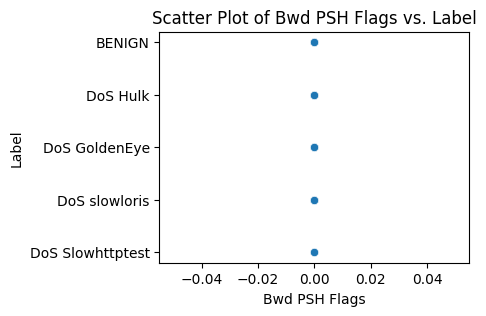

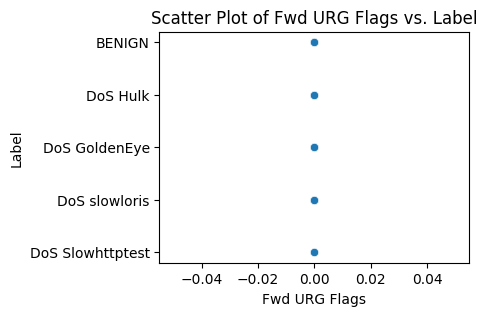

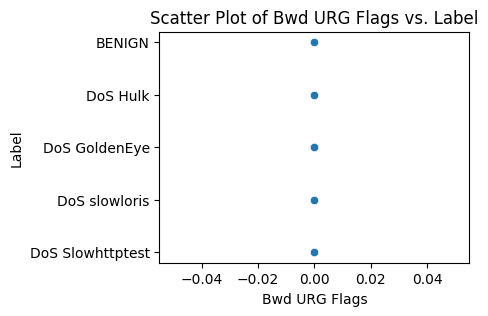

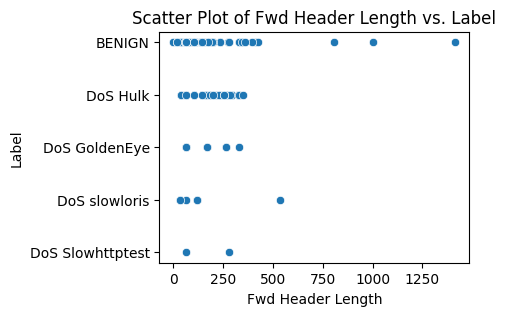

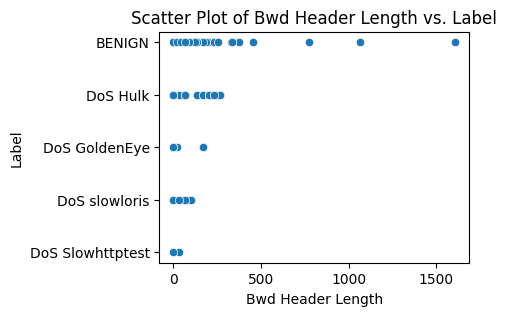

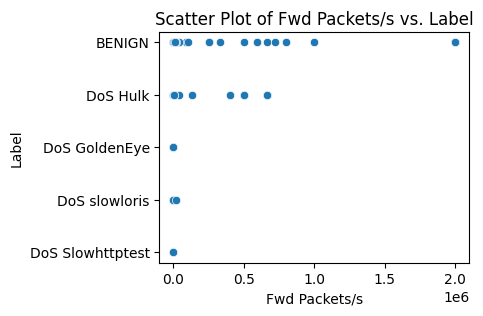

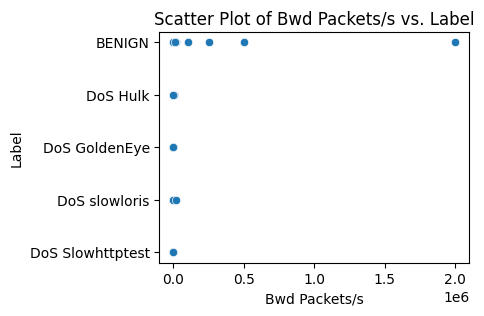

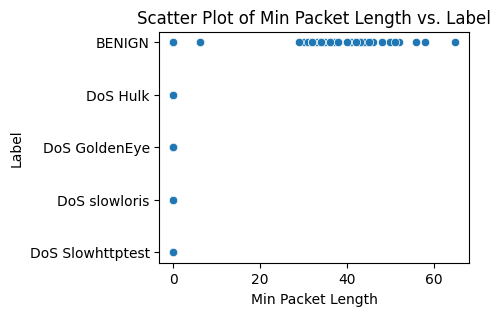

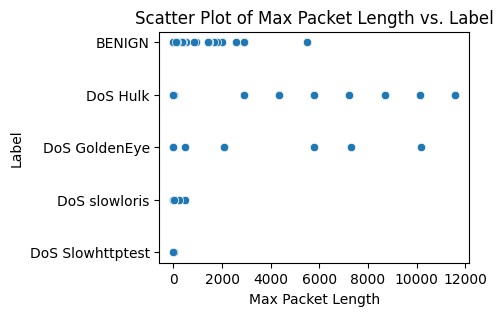

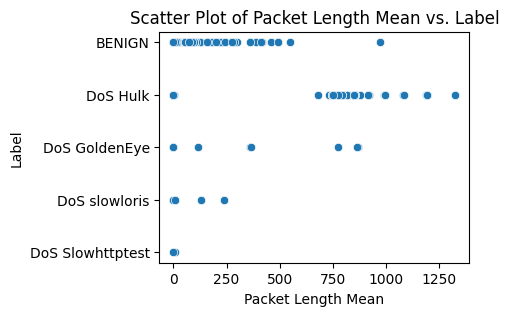

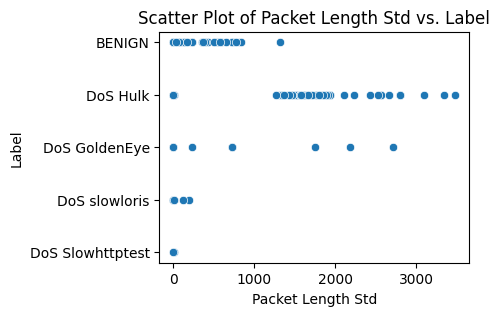

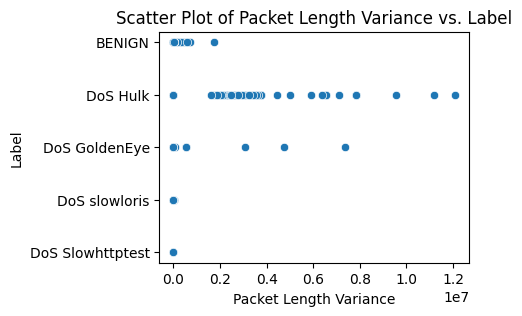

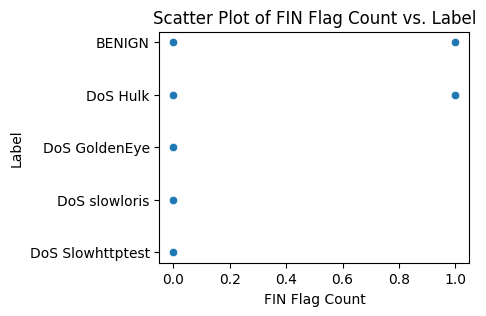

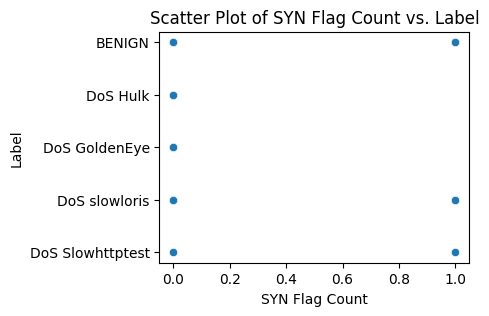

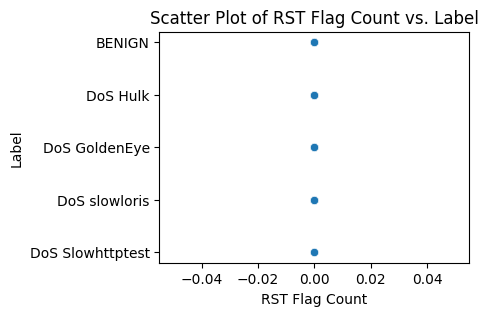

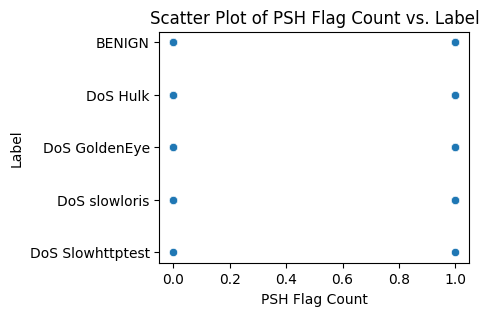

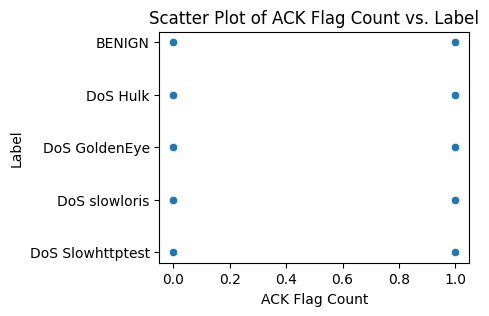

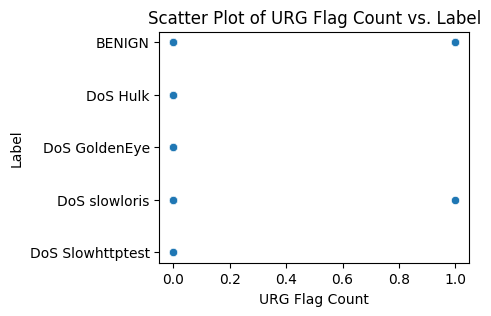

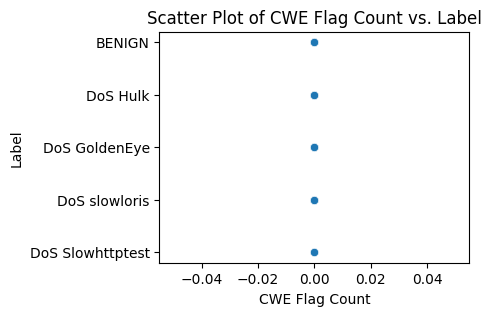

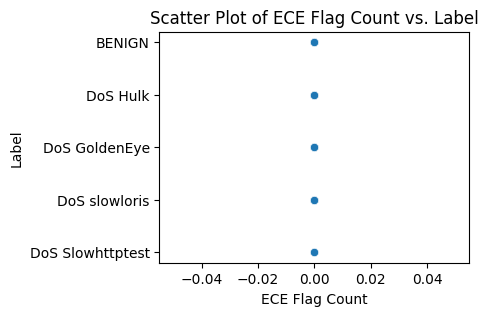

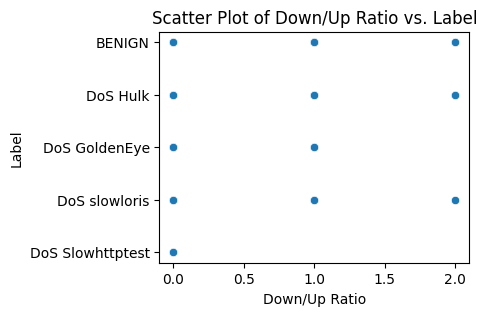

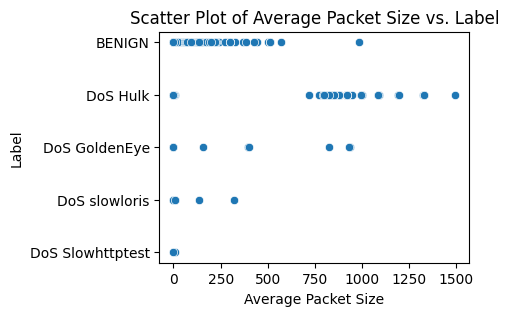

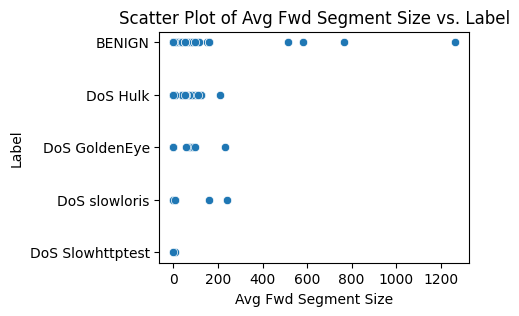

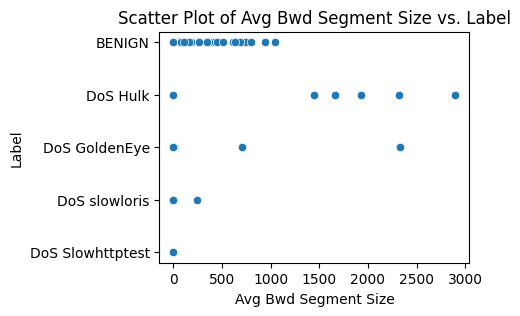

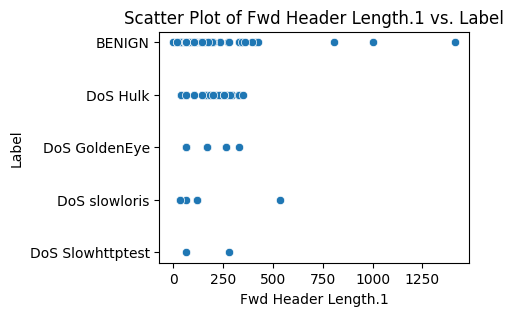

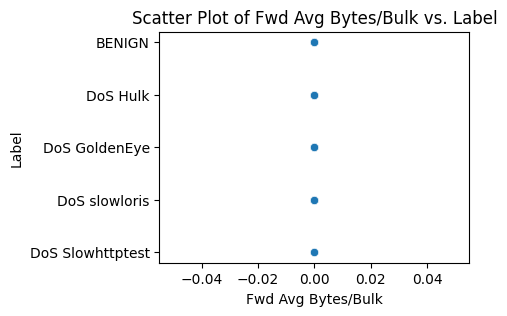

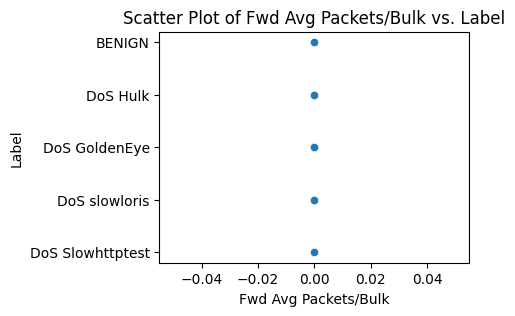

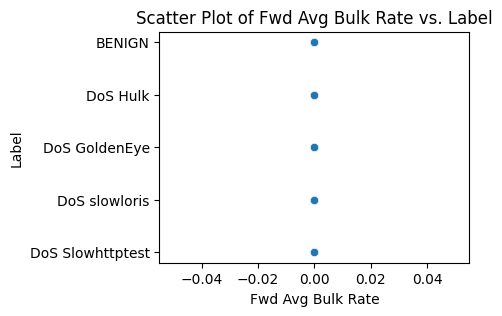

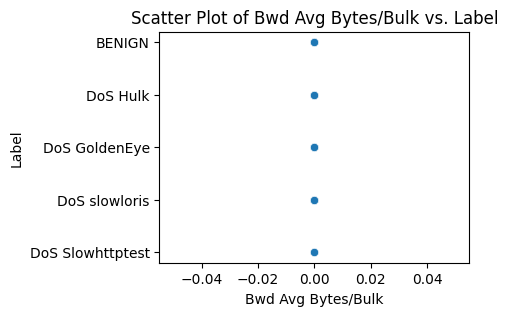

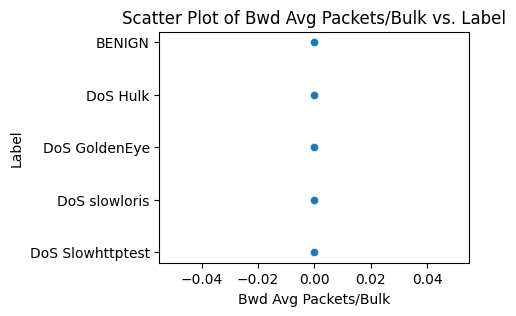

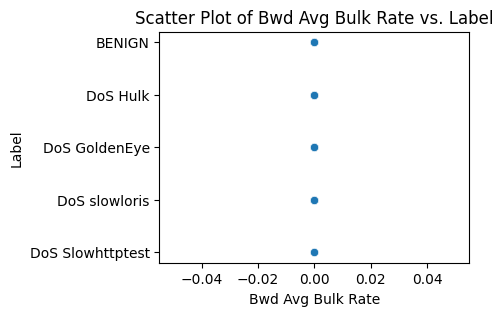

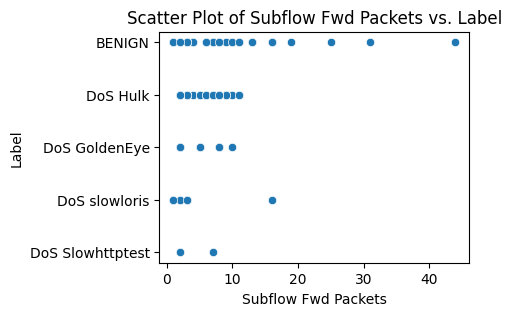

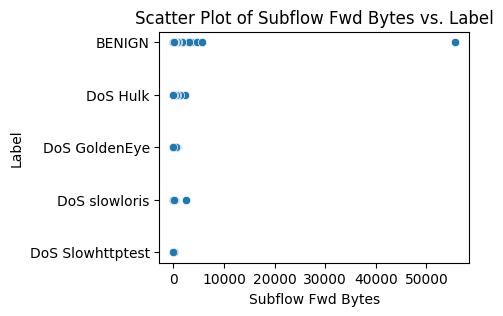

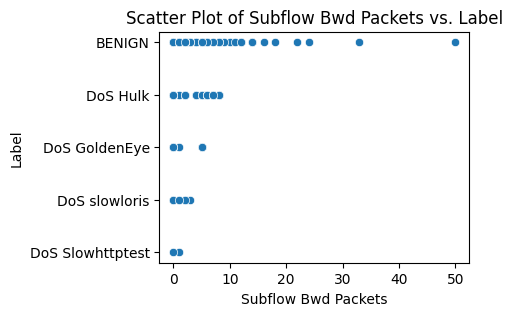

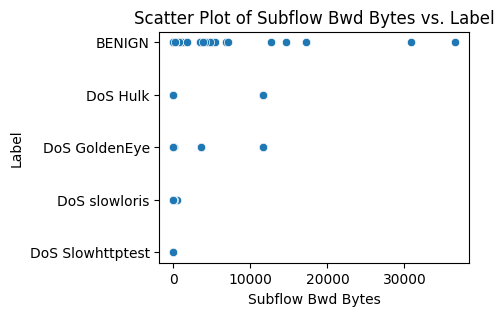

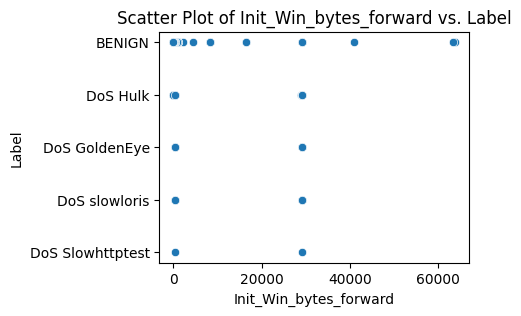

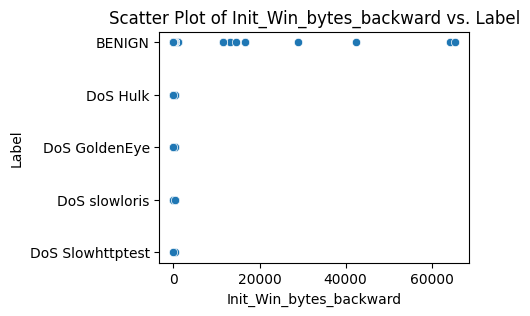

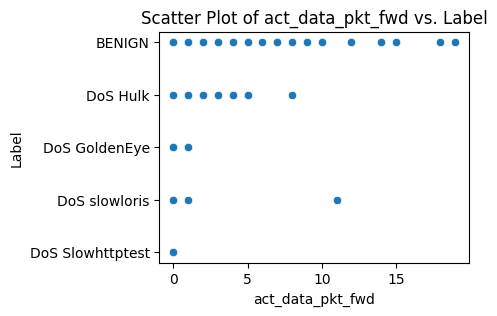

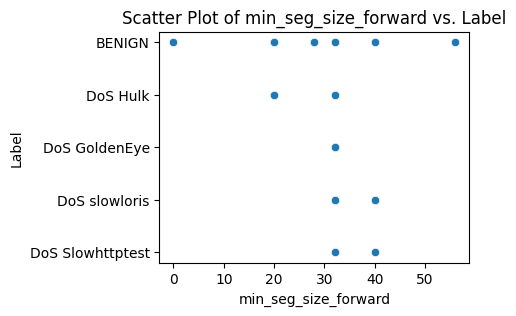

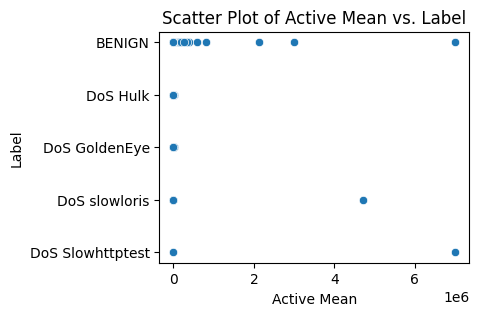

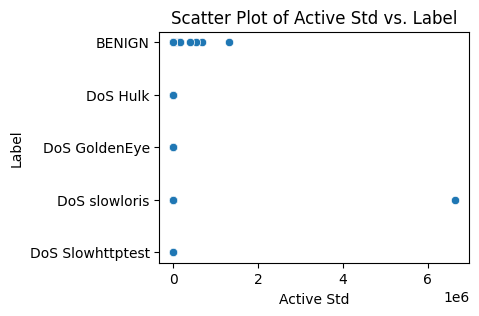

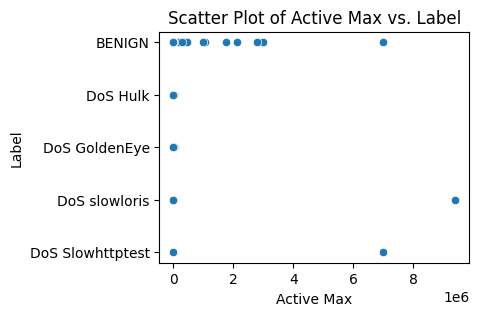

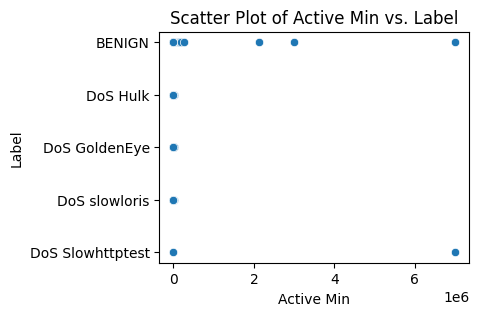

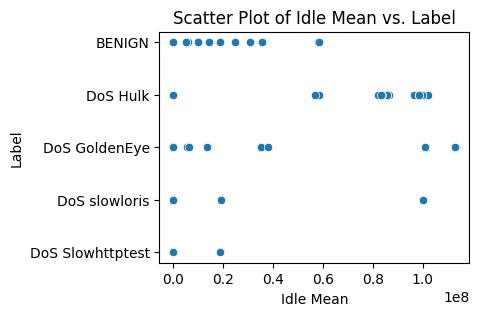

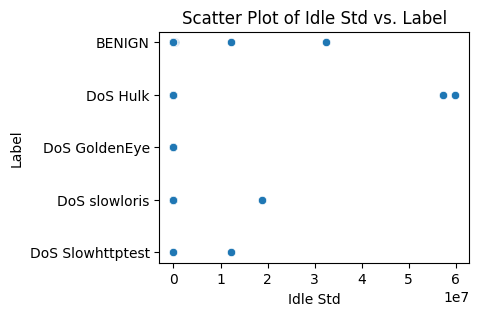

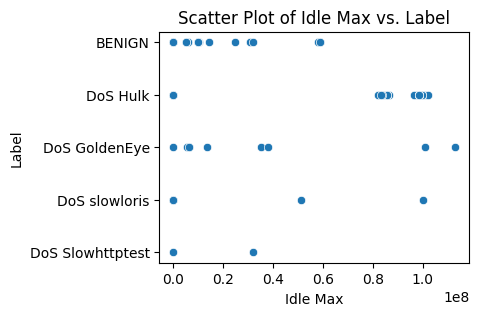

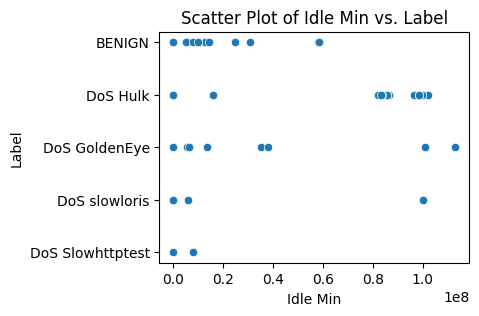

In [ ]:
#Data Visualization for Feature engineering. (Check Data Pre-Process for FSL colab)

# Load dataset
df = pd.read_csv("Wednesday_200.csv")
df = df.dropna()  # Remove missing values


# Separate features and labels
X = df.drop(columns=['Label'])
y = df['Label']

# Create scatter plots for each feature
for feature in X.columns:
  plt.figure(figsize=(4, 3))
  sns.scatterplot(x=feature, y='Label', data=df)
  plt.title(f"Scatter Plot of {feature} vs. Label")
  plt.xlabel(feature)
  plt.ylabel('Label')
  plt.show()


Data Cleaning and Pre-Processing | Feature Engineering | Pair Creation |

In [ ]:
# Ensure "Label" column is retained before feature selection
label_column = "Label"  # Assuming "Label" is the target variable

# Manually specify features to drop
features_to_drop = [
    "Total Length of Fwd Packets", "Fwd Packet Length Mean", "Fwd Packet Length Max",
    "Fwd Packet Length Min", "Fwd Packet Length Std", "Flow IAT Min", "Bwd IAT Min",
    "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags", "Bwd Packets/s",
    "FIN Flag Count", "SYN Flag Count", "RST Flag Count", "PSH Flag Count", "ACK Flag Count",
    "URG Flag Count", "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate", "Init_Win_bytes_forward", "Init_Win_bytes_backward"
]

# Check if features exist before dropping
missing_features = [feature for feature in features_to_drop if feature not in df.columns]
if missing_features:
    raise ValueError(f"Could not find features: {', '.join(missing_features)}")

df_cleaned = df.drop(columns=features_to_drop)  # Drop selected features
print(f"Removed {len(features_to_drop)} manually selected features.")

# Display remaining features
remaining_features = df_cleaned.columns.tolist()
print("Remaining features in the dataset:", remaining_features)

# Extract features and labels
X = df_cleaned.drop(columns=[label_column]).values  # Retain only selected features
y = df[label_column].values  # Keep the label column

# Normalize the feature data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Transform labels to unique integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

def create_packet_pairs(X, y):
    pairs, labels_out = [], []
    num_classes = len(set(y))

    # Group packet indices by class
    class_indices = {label: np.where(y == label)[0] for label in range(num_classes)}

    for idx in range(len(X)):
        x1 = X[idx]
        label = y[idx]

        # Positive pair (same class)
        x2 = X[np.random.choice(class_indices[label])]
        pairs.append((x1, x2))
        labels_out.append(1)

        # Negative pair (different class)
        neg_label = np.random.choice([l for l in range(num_classes) if l != label])
        x2 = X[np.random.choice(class_indices[neg_label])]
        pairs.append((x1, x2))
        labels_out.append(0)

    return np.array(pairs), np.array(labels_out)

# Use encoded labels
pairs_train, labels_train = create_packet_pairs(X, y_encoded)

Removed 29 manually selected features.
Remaining features in the dataset: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle M

In [ ]:
# Define Siamese Network
def build_siamese_network(input_shape):
    base_network = keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu", input_shape=(input_shape,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu")
    ])

    input_a = keras.Input(shape=(input_shape,))
    input_b = keras.Input(shape=(input_shape,))

    processed_a = base_network(input_a)
    processed_b = base_network(input_b)

    # Compute absolute difference
    distance = tf.keras.layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([processed_a, processed_b])

    # Fully connected layer to determine similarity
    output = tf.keras.layers.Dense(1, activation="sigmoid")(distance) #sigmoid is also hyperparameter. can be tuned

    return keras.Model(inputs=[input_a, input_b], outputs=output)

# Compile the model
siamese_model = build_siamese_network(X.shape[1])
siamese_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]) #hyperparamet. check chatGPT for other option bracu g-suit email.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


train test 10/90 split. 20 Sample for Train, 180 for test.

In [ ]:

# Reshape data
pairs_train = pairs_train.reshape((-1, 2, X.shape[1])) #[X.shape[1] ensures that selected features have values inside them, 0 doesnt count. taking first 10 features that has values]


#Split data (10% train, 90% test)
pairs_train, pairs_test, labels_train, labels_test = train_test_split(
    pairs_train, labels_train, test_size=0.9, random_state=42
)

#Train on 10%, evaluate on 90%
siamese_model.fit([pairs_train[:, 0], pairs_train[:, 1]], labels_train,
                  batch_size=16, epochs=50, validation_data=([pairs_test[:, 0], pairs_test[:, 1]], labels_test))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.4641 - loss: 0.7976 - val_accuracy: 0.4861 - val_loss: 0.6999
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5906 - loss: 0.6643 - val_accuracy: 0.5111 - val_loss: 0.6942
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.5413 - val_accuracy: 0.5250 - val_loss: 0.6920
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8625 - loss: 0.5186 - val_accuracy: 0.5306 - val_loss: 0.6909
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9156 - loss: 0.4593 - val_accuracy: 0.5139 - val_loss: 0.6911
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9187 - loss: 0.4217 - val_accuracy: 0.5222 - val_loss: 0.6915
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9516 - loss: 0.3605 - val_accuracy: 0.5389 - val_loss: 0.6906
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.3472 - val_accuracy: 0.5472 - val_loss: 0.6889

Evaluation with Graphics

In [ ]:
# Reshape test pairs
#pairs_test = pairs_train.reshape((-1, 2, X.shape[1]))
pairs_test = pairs_train.reshape((-1, 2, 49))

# Compute Manhattan distance between the pairs
y_pred_prob = siamese_model.predict([pairs_test[:, 0], pairs_test[:, 1]])
y_pred = (y_pred_prob.ravel() > 0.5).astype(int)  # Threshold for binary classification [DO NOT TOUCH]

# Calculate evaluation metrics
accuracy = accuracy_score(labels_train, y_pred)
precision = precision_score(labels_train, y_pred)
recall = recall_score(labels_train, y_pred)
f1 = f1_score(labels_train, y_pred)
conf_matrix = confusion_matrix(labels_train, y_pred)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9500
F1 Score: 0.9744
Confusion Matrix:
[[20  0]
 [ 1 19]]


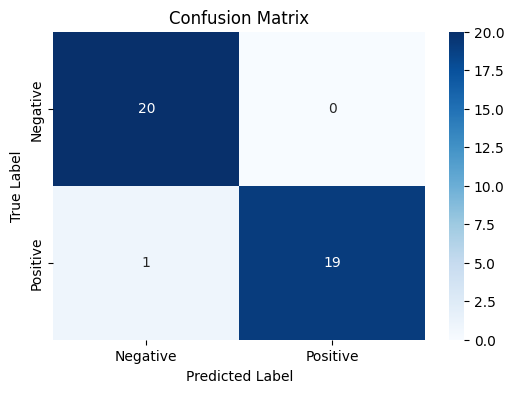

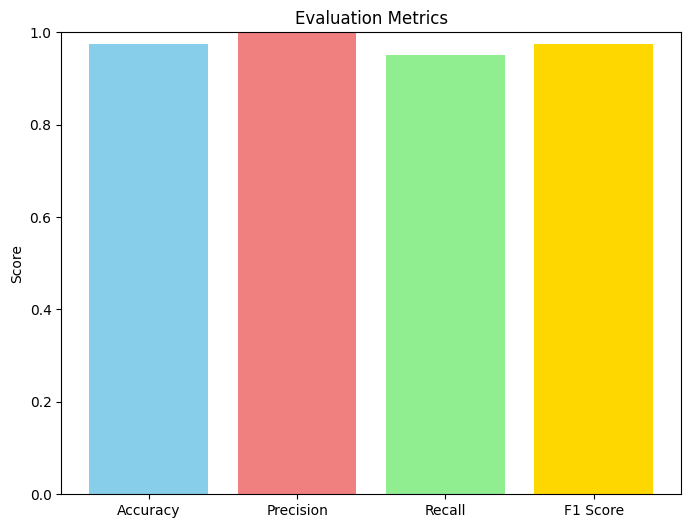

In [ ]:
# prompt: make visual representation of the evaluation

import matplotlib.pyplot as plt
import seaborn as sns

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Plot evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.0)  # Set y-axis limit to 0-1 for clarity
plt.show()
